<a href="https://colab.research.google.com/github/par21val-512/rosalind/blob/main/copy_of_smbpls_scvi_complete_tejas_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install --quiet anndata mudata scvi-colab
from scvi_colab import install
install()

# Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import mudata as mu
import scvi
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scvi.module.base import BaseModuleClass, LossOutput
import scanpy as sc
RANDOM_SEED = 42

# Simulate data

Same setup as the main notebook. We wrap everything in MuData/AnnData instead of raw tensors.

In [ ]:
def simulate_mudata(seed=42, n=5000, noise=0.0):
    torch.manual_seed(seed)
    p1, p2, p3, k = 50, 80, 30, 2

    # true latent scores for all cells
    z = torch.normal(0, 1, size=(n, k))

    # sparse version: first half only has component 1, second half only component 2
    z_sp = z.clone()
    z_sp[:2500, 0] = 0
    z_sp[2500:, 1] = 0

    # random loading matrices (true weights, not learned)
    w1 = torch.randn(p1, k)
    w2 = torch.randn(p2, k)
    w3 = torch.randn(p3, k)

    # generate each block as linear combination of latent scores + noise
    x1 = z_sp @ w1.T + noise * torch.randn(n, p1)
    x2 = z_sp @ w2.T + noise * torch.randn(n, p2)
    x3 = z_sp @ w3.T + noise * torch.randn(n, p3)

    idx = np.arange(n)
    tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=seed)
    split = np.array(['train'] * n)
    split[te_idx] = 'test'

    # wrap each block in AnnData — rows are cells, cols are features
    def make_adata(X, name):
        adata = ad.AnnData(X=X.numpy())
        adata.obs['split'] = split
        adata.var_names = [f'{name}_{i}' for i in range(X.shape[1])]
        return adata

    mod1 = make_adata(x1, 'rna')
    mod2 = make_adata(x2, 'atac')
    mod3 = make_adata(x3, 'prot')

    # target y stored in obsm so it travels with the data object
    mod1.obsm['y'] = z_sp.numpy()

    mdata = mu.MuData({'rna': mod1, 'atac': mod2, 'prot': mod3})
    return mdata

MuData object with n_obs × n_vars = 5000 × 160
  3 modalities
    rna:	5000 x 50
      obs:	'split'
      obsm:	'y'
    atac:	5000 x 80
      obs:	'split'
    prot:	5000 x 30
      obs:	'split'


/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


# sMBPLS Module

Core model logic. Inherits from BaseModuleClass to fit the scvi module interface.

In [ ]:
def soft_threshold(x, lam):
    # zero out weights smaller than lam, shrink the rest toward zero
    if lam <= 0:
        return x
    return torch.sign(x) * torch.clamp(torch.abs(x) - lam, min=0.0)


class SMBPLSModule(BaseModuleClass):
    def __init__(self, n_input_per_mod, n_output=2, n_components=2, lam_w=0.05, lam_t=0.0):
        super().__init__()
        self.mod_names = list(n_input_per_mod.keys())
        self.K = n_components
        self.lam_w = lam_w
        self.lam_t = lam_t
        alpha = 1.0 / len(self.mod_names)  # equal block weights by default
        self.alpha = {m: alpha for m in self.mod_names}

        # one linear projection per modality: (n, p_b) -> (n, K)
        # no bias — these are PLS-style loadings, not a full NN layer
        self.proj = nn.ModuleDict({
            m: nn.Linear(n_input_per_mod[m], self.K, bias=False)
            for m in self.mod_names
        })

        # regression head maps latent scores to the outcome
        self.regressor = nn.Linear(self.K, n_output, bias=True)

        for m in self.mod_names:
            nn.init.normal_(self.proj[m].weight, std=0.02)
        nn.init.zeros_(self.regressor.bias)

    @torch.no_grad()
    def apply_sparsity(self):
        # proximal L1 step on loadings — called periodically during training
        for m in self.mod_names:
            W = self.proj[m].weight
            W.copy_(soft_threshold(W, self.lam_w))

    def _get_inference_input(self, tensors):
        return {m: tensors[m] for m in self.mod_names}

    def _get_generative_input(self, tensors, inference_outputs):
        return {'t': inference_outputs['t']}

    def inference(self, **block_data):
        # compute composite latent score t from all blocks
        t = None
        for m in self.mod_names:
            tb = self.proj[m](block_data[m])
            t = tb * self.alpha[m] if t is None else t + tb * self.alpha[m]

        # optional observation-level sparsity (zeroes out inactive cells)
        if self.lam_t > 0:
            t = soft_threshold(t, self.lam_t)
        return {'t': t}

    def generative(self, t):
        y_hat = self.regressor(t)
        return {'y_hat': y_hat}

    def loss(self, tensors, inference_outputs, generative_outputs):
        y = tensors['y'].float() if isinstance(tensors['y'], torch.Tensor) else torch.tensor(tensors['y'], dtype=torch.float32)
        y_hat = generative_outputs['y_hat']
        t = inference_outputs['t']

        # main regression loss
        mse = F.mse_loss(y_hat, y)

        # covariance objective (PLS-style)
        T = t - t.mean(0)
        yc = y - y.mean(0)
        cov = (T.T @ yc) / (T.shape[0] - 1)
        cov_loss = -(cov ** 2).sum() / (T.shape[1] * y.shape[1])

        # orthogonality constraint on latent scores
        Tn = T / (T.norm(dim=0, keepdim=True) + 1e-8)
        I = torch.eye(self.K, device=T.device)
        orth_loss = torch.norm(Tn.T @ Tn - I, p="fro") ** 2

        loss = mse + 0.1 * cov_loss + 0.1 * orth_loss

        return LossOutput(loss=loss, n_obs_minibatch=t.shape[0])


# SMBPLS model class

User-facing class similar to how you would use scvi.model.SCVI.
Handles setup_mudata, train, get_latent_representation, and get_loadings.

In [ ]:
class SMBPLS:
    """
    Sparse Multi-Block PLS for multi-omics MuData.

    Usage
    -----
    SMBPLS.setup_mudata(mdata, modalities=['rna', 'atac', 'prot'], y_obsm_key='y', y_mod='rna')
    model = SMBPLS(mdata, n_components=2, lam_w=0.05)
    model.train(max_epochs=300)
    z = model.get_latent_representation()
    loadings = model.get_loadings()
    """

    def __init__(self, mdata, n_outputs=2, n_components=2, lam_w=0.05, lam_t=0.0):
        self.mdata = mdata
        n_input = {m: mdata[m].n_vars for m in mdata.mod_names}
        self.module = SMBPLSModule(
            n_input_per_mod=n_input,
            n_output=n_outputs,
            n_components=n_components,
            lam_w=lam_w,
            lam_t=lam_t,
        )

    @classmethod
    def setup_mudata(cls, mdata, modalities, y_obsm_key='y', y_mod='rna'):
        # store config on the mdata object so the model can find it later
        mdata.uns['smbpls_modalities'] = modalities
        mdata.uns['smbpls_y_mod'] = y_mod
        mdata.uns['smbpls_y_key'] = y_obsm_key
        print(f"Registered modalities: {modalities}, target: {y_mod}.obsm['{y_obsm_key}']")

    def train(self, max_epochs=300, lr=1e-3, batch_size=256, sparsity_freq=50):
        mdata = self.mdata
        mods = mdata.uns['smbpls_modalities']
        y_mod = mdata.uns['smbpls_y_mod']
        y_key = mdata.uns['smbpls_y_key']

        # build tensors from mudata — multi-block batching is custom so we skip scvi's dataloader
        X_blocks = {m: torch.tensor(mdata[m].X, dtype=torch.float32) for m in mods}
        y = torch.tensor(mdata[y_mod].obsm[y_key], dtype=torch.float32)

        n = y.shape[0]
        idx = np.arange(n)
        tr, te = train_test_split(idx, test_size=0.2, random_state=42)

        X_tr = {m: X_blocks[m][tr] for m in mods}
        X_te = {m: X_blocks[m][te] for m in mods}
        y_tr, y_te = y[tr], y[te]

        opt = torch.optim.Adam(self.module.parameters(), lr=lr)
        self._train_losses, self._val_losses = [], []

        self.module.train()
        for epoch in range(max_epochs):
            perm = torch.randperm(len(tr))
            epoch_loss = 0.0
            n_batches = 0
            for start in range(0, len(tr), batch_size):
                batch_idx = perm[start:start + batch_size]
                Xb = {m: X_tr[m][batch_idx] for m in mods}
                yb = y_tr[batch_idx]

                opt.zero_grad()
                inf = self.module.inference(**Xb)
                gen = self.module.generative(inf['t'])
                loss_out = self.module.loss({'y': yb}, inf, gen)
                loss_out.loss.backward()
                opt.step()
                epoch_loss += loss_out.loss.item()
                n_batches += 1

            if epoch % sparsity_freq == 0:
                self.module.apply_sparsity()

            avg_loss = epoch_loss / n_batches
            self._train_losses.append(avg_loss)

            if epoch % 50 == 0:
                self.module.eval()
                with torch.no_grad():
                    inf_te = self.module.inference(**X_te)
                    gen_te = self.module.generative(inf_te['t'])
                    val_mse = F.mse_loss(gen_te['y_hat'], y_te).item()
                self._val_losses.append((epoch, val_mse))
                print(f'epoch {epoch:>4} | train loss {avg_loss:.4f} | val MSE {val_mse:.4f}')
                self.module.train()

        self.is_trained_ = True
        print('Training done.')

    @torch.no_grad()
    def get_latent_representation(self, mdata=None):
        if mdata is None:
            mdata = self.mdata
        mods = mdata.uns['smbpls_modalities']
        X_blocks = {m: torch.tensor(mdata[m].X, dtype=torch.float32) for m in mods}

        self.module.eval()
        inf = self.module.inference(**X_blocks)
        T = inf['t'].numpy()

        # store so scanpy/muon can pick it up directly from obsm
        mdata.obsm['X_smbpls'] = T
        print(f"Latent scores stored in mdata.obsm['X_smbpls'], shape {T.shape}")
        return T

    @torch.no_grad()
    def get_loadings(self):
        mdata = self.mdata
        mods = mdata.uns['smbpls_modalities']
        loadings = {}
        for m in mods:
            W = self.module.proj[m].weight.numpy()  # shape (K, p_b)
            var_names = mdata[m].var_names.tolist()
            df = pd.DataFrame(W.T, index=var_names,
                              columns=[f'component_{k+1}' for k in range(self.module.K)])
            loadings[m] = df
        return loadings

    def save(self, path):
        torch.save(self.module.state_dict(), path)
        print(f'Model weights saved to {path}')

    def load(self, path):
        self.module.load_state_dict(torch.load(path))
        print(f'Model weights loaded from {path}')

    def plot_training(self):
        plt.figure()
        plt.plot(self._train_losses)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training loss')
        plt.show()

# Run the model

Registered modalities: ['rna', 'atac', 'prot'], target: rna.obsm['y']


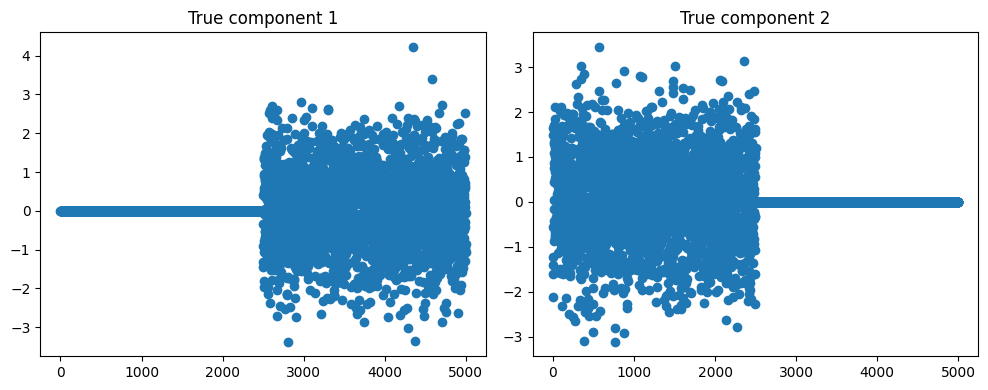

epoch    0 | train loss 0.5032 | val MSE 0.5318
epoch   50 | train loss 0.2442 | val MSE 0.5300
epoch  100 | train loss 0.0033 | val MSE 0.4615
epoch  150 | train loss -0.0135 | val MSE 0.4086
epoch  200 | train loss -0.0119 | val MSE 0.4008
epoch  250 | train loss -0.0118 | val MSE 0.4059
epoch  300 | train loss -0.0116 | val MSE 0.4093
epoch  350 | train loss -0.0134 | val MSE 0.4173
epoch  400 | train loss -0.0151 | val MSE 0.4170
epoch  450 | train loss -0.0192 | val MSE 0.4039
Training done.


In [ ]:
mdata = simulate_mudata()
print(mdata)
SMBPLS.setup_mudata(mdata, modalities=['rna', 'atac', 'prot'], y_obsm_key='y', y_mod='rna')

Z = mdata['rna'].obsm['y']
n_cells = Z.shape[0]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
  ax.scatter(range(n_cells), Z[:,i])
  ax.set_title(f"True component {i+1}")
plt.tight_layout()
plt.show()

model = SMBPLS(mdata, n_components=2, lam_w=0.05)
model.train(max_epochs=500, lr=5e-4, batch_size=256)

# Latent scores

Latent scores stored in mdata.obsm['X_smbpls'], shape (5000, 2)


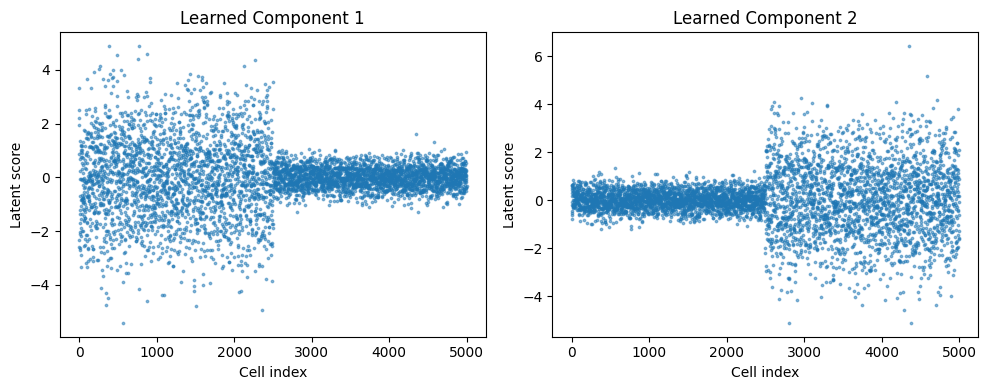

In [ ]:
T = model.get_latent_representation()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.scatter(np.arange(len(T)), T[:, i], s=3, alpha=0.5)
    ax.set_title(f'Learned Component {i+1}')
    ax.set_xlabel('Cell index')
    ax.set_ylabel('Latent score')
plt.tight_layout()
plt.show()

Latent scores stored in mdata.obsm['X_smbpls'], shape (5000, 2)
Correlation Between Z_true and latent components T: 
[[ 0.2418256   0.9707322 ]
 [-0.97034323  0.24007016]]


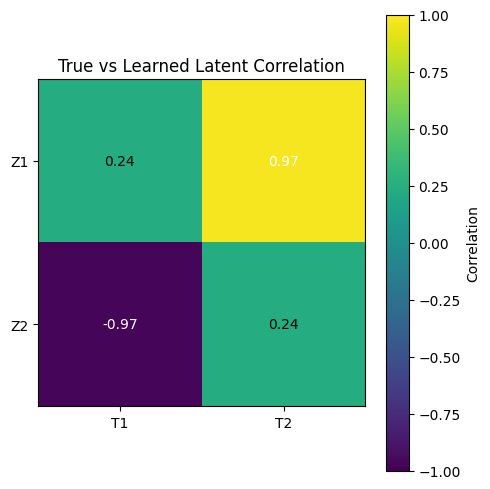

In [ ]:
Z_true = mdata["rna"].obsm["y"]
T = model.get_latent_representation()

print('Correlation Between Z_true and latent components T: ')
C = np.corrcoef(Z_true.T, T.T)[:2, 2:]
print(C)
fig, ax = plt.subplots(figsize=(5,5))

im = ax.imshow(C, vmin=-1, vmax=1)

# axis labels
ax.set_xticks(range(C.shape[1]))
ax.set_yticks(range(C.shape[0]))
ax.set_xticklabels(["T1", "T2"])
ax.set_yticklabels(["Z1", "Z2"])

# write numbers in cells
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        ax.text(j, i, f"{C[i,j]:.2f}",
                ha="center", va="center",
                color="white" if abs(C[i,j]) > 0.5 else "black")

plt.colorbar(im, ax=ax, label="Correlation")
plt.title("True vs Learned Latent Correlation")

plt.tight_layout()
plt.show()


# Loadings — which features got selected per modality

rna: [50 50] non-zero loadings per component
atac: [80 80] non-zero loadings per component
prot: [30 30] non-zero loadings per component


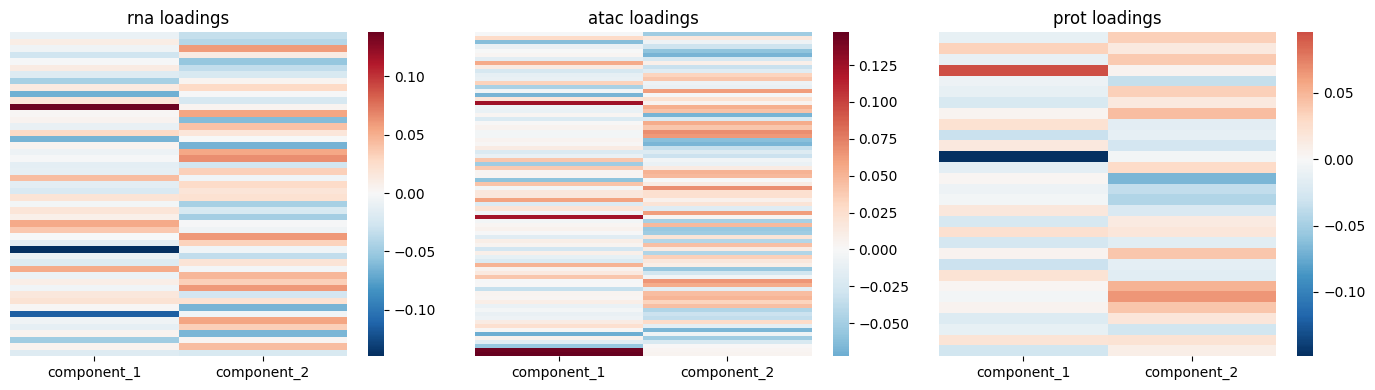

In [ ]:
loadings = model.get_loadings()

for mod_name, df in loadings.items():
    n_nonzero = (df.abs() > 1e-6).sum()
    print(f'{mod_name}: {n_nonzero.values} non-zero loadings per component')

import seaborn as sns
fig, axes = plt.subplots(1, len(loadings), figsize=(14, 4))
for ax, (mod_name, df) in zip(axes, loadings.items()):
    mask = (df.abs() > 1e-6).any(axis=1)
    sub = df[mask]
    if sub.shape[0] == 0:
        sub = df
    sns.heatmap(sub, ax=ax, center=0, cmap='RdBu_r', yticklabels=False)
    ax.set_title(f'{mod_name} loadings')
plt.tight_layout()
plt.show()

# Predicted vs true latent scores

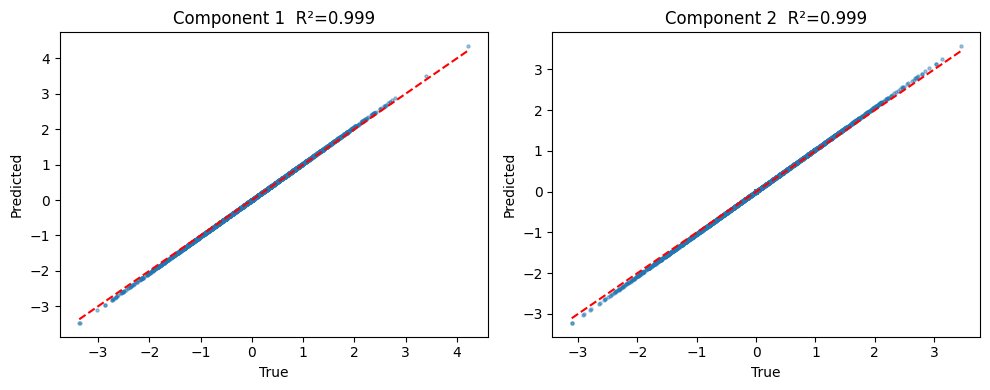

In [ ]:
mods = mdata.uns['smbpls_modalities']
y_mod = mdata.uns['smbpls_y_mod']
y_key = mdata.uns['smbpls_y_key']

X_all = {m: torch.tensor(mdata[m].X, dtype=torch.float32) for m in mods}
y_all = mdata[y_mod].obsm[y_key]

model.module.eval()
with torch.no_grad():
    inf = model.module.inference(**X_all)
    gen = model.module.generative(inf['t'])
    y_hat = gen['y_hat'].numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.scatter(y_all[:, i], y_hat[:, i], s=5, alpha=0.4)
    mn, mx = y_all[:, i].min(), y_all[:, i].max()
    ax.plot([mn, mx], [mn, mx], 'r--')
    r2 = r2_score(y_all[:, i], y_hat[:, i])
    ax.set_title(f'Component {i+1}  R²={r2:.3f}')
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
plt.tight_layout()
plt.show()

# UMAP of latent space

Scanpy works directly with values stored in mdata.obsm.

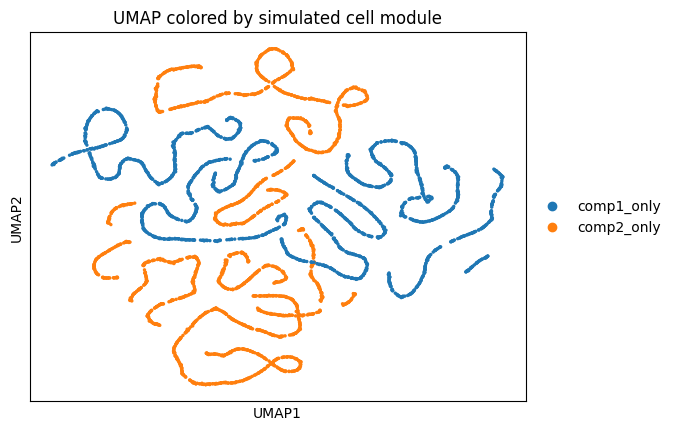

In [ ]:
# use rna modality as the reference adata for scanpy
adata_ref = mdata['rna'].copy()
adata_ref.obsm['X_smbpls'] = T

sc.pp.neighbors(adata_ref, use_rep='X_smbpls', n_neighbors=15)
sc.tl.umap(adata_ref)

# color by which latent component is active — matches our simulated structure
adata_ref.obs['active_component'] = 'both'
adata_ref.obs.loc[adata_ref.obs.index[:2500], 'active_component'] = 'comp2_only'
adata_ref.obs.loc[adata_ref.obs.index[2500:], 'active_component'] = 'comp1_only'

sc.pl.umap(adata_ref, color='active_component', title='UMAP colored by simulated cell module')

# Training curve

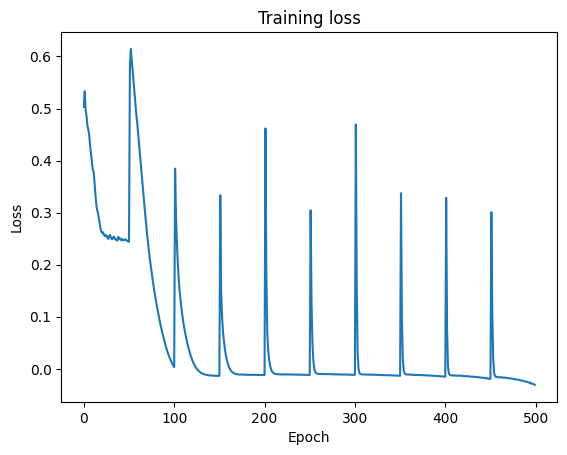

In [ ]:
model.plot_training()

# Save and reload model weights

In [ ]:
model.save('smbpls_weights_simulation.pt')

# to reload later:
model2 = SMBPLS(mdata, n_components=2, lam_w=0.05)
model2.load('smbpls_weights_simulation.pt')

Model weights saved to smbpls_weights_simulation.pt
Model weights loaded from smbpls_weights_simulation.pt


Latent scores stored in mdata.obsm['X_smbpls'], shape (5000, 2)


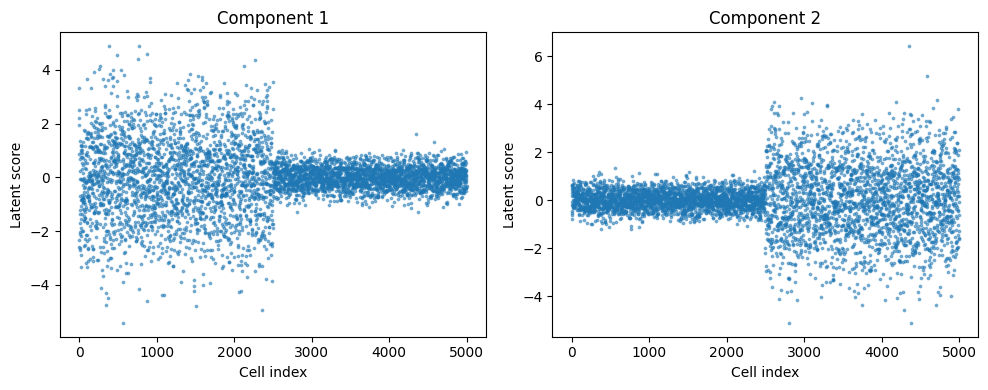

In [ ]:
T = model2.get_latent_representation()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.scatter(np.arange(len(T)), T[:, i], s=3, alpha=0.5)
    ax.set_title(f'Component {i+1}')
    ax.set_xlabel('Cell index')
    ax.set_ylabel('Latent score')
plt.tight_layout()
plt.show()

# Real data deployment

In [ ]:
! pip install --quiet scvelo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.2/191.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.7 MB/s eta 0:00:00


In [ ]:
from scvelo import datasets

adata = datasets.gastrulation()

  0%|          | 0.00/4.37G [00:00<?, ?B/s]

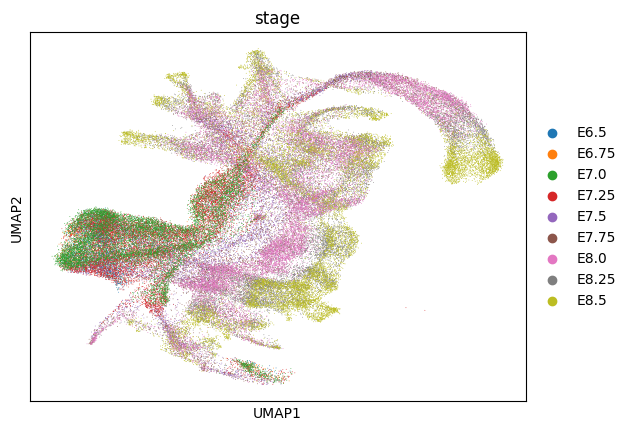

In [ ]:
sc.pl.umap(adata, color=["stage"])

In [ ]:
mdata = mu.MuData({'rna': adata})
adata

AnnData object with n_obs × n_vars = 89267 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'stage_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

In [ ]:
import pandas as pd
import numpy as np
import mudata as mu
import anndata as ad
from sklearn.model_selection import train_test_split

# 1. Prepare target
y_dummies = pd.get_dummies(adata.obs['stage']).astype(float).values

# 2. Train/test split
idx = np.arange(adata.n_obs)
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=42)

split = np.array(['train'] * adata.n_obs)
split[te_idx] = 'test'

# 3. Block 1: spliced PCA
adata_spliced = ad.AnnData(X=adata.obsm["X_pca"].copy())
adata_spliced.obs = adata.obs.copy()
adata_spliced.obs["split"] = split
adata_spliced.obsm["stage_onehot"] = y_dummies

# 4. Block 2: unspliced PCA
adata_unspliced = ad.AnnData(X=adata.obsm["X_pca"].copy())
adata_unspliced.obs = adata.obs.copy()
adata_unspliced.obs["split"] = split
adata_unspliced.obsm["stage_onehot"] = y_dummies

# 5. Wrap in MuData
mdata_real = mu.MuData({
    "spliced": adata_spliced,
    "unspliced": adata_unspliced
})

# 6. Setup SMBPLS
SMBPLS.setup_mudata(
    mdata_real,
    modalities=["spliced", "unspliced"],
    y_obsm_key="stage_onehot",
    y_mod="spliced"
)

# 7. Train
model_real = SMBPLS(
    mdata_real,
    n_outputs=y_dummies.shape[1],
    n_components=5,
    lam_w=0.01
)

model_real.train(max_epochs=200, lr=1e-3, batch_size=512)


NameError: name 'adata' is not defined

In [ ]:
model_real.plot_training()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

y_true = mdata_real['rna'].obsm['stage_onehot']
y_pred = model_real.get_latent_representation(mdata_real)

# 1. Convert probabilities/logits to class indices
# y_pred comes from the previous cell's output
predicted_classes = np.argmax(y_pred, axis=1)
true_classes = np.argmax(y_true, axis=1)

# 2. Print Classification Report
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=stage_names))

# 3. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(true_classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=stage_names)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix: Predicted vs True Developmental Stage')
plt.show()

TODO For Next Week:
- Test out different covariance loss terms
- Discuss orthogonality penalization vs. delfating separately
- Celltype UMAP, Embryo Date UMAP, PLS Component coloring UMAP,

In [ ]:
! pip install mbpls